In [30]:
# Dataset already available locally in ./afhq/
import os
data_dir = './afhq'
print("Dataset contents:", os.listdir(data_dir))

Dataset contents: ['train', 'val']


In [ ]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import pickle
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device Available: ", device)

Device Available:  cpu


In [32]:
image_path = []
labels = []

for i in os.listdir(data_dir):
  for label in os.listdir(f"{data_dir}/{i}"):
    for image in os.listdir(f"{data_dir}/{i}/{label}"):
      image_path.append(f"{data_dir}/{i}/{label}/{image}")
      labels.append(label)

data_df = pd.DataFrame(zip(image_path, labels), columns = ["image_path", "labels"])
print(data_df["labels"].unique())
data_df.head()

['cat' 'dog' 'wild']


,image_path,labels
0,./afhq/train/cat/flickr_cat_000002.jpg,cat
1,./afhq/train/cat/flickr_cat_000003.jpg,cat
2,./afhq/train/cat/flickr_cat_000004.jpg,cat
3,./afhq/train/cat/flickr_cat_000005.jpg,cat
4,./afhq/train/cat/flickr_cat_000006.jpg,cat


In [33]:
train = data_df.sample(frac = 0.7)
test = data_df.drop(train.index)

val = test.sample(frac = 0.5)
test = test.drop(val.index)

print(train.shape, test.shape, val.shape)

(11291, 2) (2419, 2) (2420, 2)


In [34]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df["labels"])

train_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

val_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [35]:
class CustomImageDataset(Dataset):
  def __init__(self, dataframe, transform = None):
    self.dataframe = dataframe
    self.transform = transform
    self.labels = torch.tensor(label_encoder.transform(dataframe['labels'])).to(device)

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx, 0]
    label = self.labels[idx]

    image = Image.open(img_path).convert('RGB')

    if self.transform:
      image = self.transform(image).to(device)

    return image, label
     

In [36]:
train_dataset = CustomImageDataset(dataframe = train, transform = train_transform)
test_dataset = CustomImageDataset(dataframe = test, transform = val_transform)
val_dataset = CustomImageDataset(dataframe = val, transform = val_transform)

In [37]:
print(train.iloc[2, 0])

./afhq/train/cat/pixabay_cat_004680.jpg


In [38]:

train_dataset.__getitem__(2)

(tensor([[[0.0000, 0.4196, 0.4157,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.4078, 0.4039,  ..., 0.4510, 0.4745, 0.5333],
          [0.0000, 0.3882, 0.3804,  ..., 0.4275, 0.4902, 0.5922],
          ...,
          [0.4000, 0.4196, 0.4353,  ..., 0.2078, 0.2235, 0.0000],
          [0.4039, 0.4392, 0.4471,  ..., 0.2118, 0.2157, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.2118, 0.2157, 0.0000]],
 
         [[0.0000, 0.4667, 0.4627,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.4549, 0.4510,  ..., 0.1804, 0.1843, 0.2314],
          [0.0000, 0.4353, 0.4314,  ..., 0.1725, 0.2039, 0.2745],
          ...,
          [0.3922, 0.4118, 0.4275,  ..., 0.1451, 0.1608, 0.0000],
          [0.3961, 0.4314, 0.4392,  ..., 0.1490, 0.1529, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.1490, 0.1529, 0.0000]],
 
         [[0.0000, 0.4667, 0.4627,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.4549, 0.4510,  ..., 0.0588, 0.0353, 0.0549],
          [0.0000, 0.4353, 0.4314,  ...,

In [39]:

label_encoder.inverse_transform([0])

array(['cat'], dtype=object)

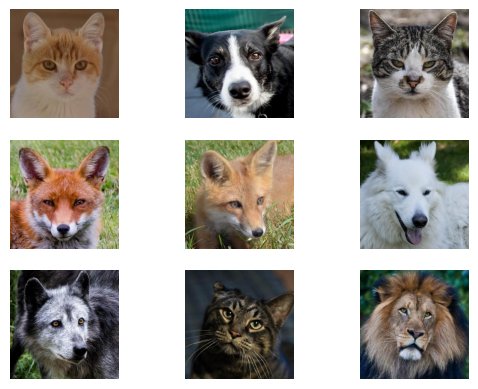

In [40]:
n_rows = 3
n_cols = 3

f, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
  for col in range(n_cols):
    image = Image.open(data_df.sample(n=1)["image_path"].iloc[0]).convert("RGB")
    axarr[row, col].imshow(image)
    axarr[row, col].axis('off')

In [41]:

LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 20

In [42]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [43]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding= 1)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding= 1)
    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding= 1)

    self.pooling = nn.MaxPool2d(2, 2)

    self.relu = nn.ReLU()

    self.flatten = nn.Flatten()
    self.linear = nn.Linear((128*16*16), 128)
    self.dropout = nn.Dropout(0.5)
    self.output = nn.Linear(128, len(data_df['labels'].unique()))

  def forward(self, x):
    x = self.conv1(x)
    x = self.pooling(x)
    x = self.relu(x)

    x = self.conv2(x)
    x = self.pooling(x)
    x = self.relu(x)

    x = self.conv3(x)
    x = self.pooling(x)
    x = self.relu(x)

    x = self.flatten(x)
    x = self.linear(x)
    x = self.relu(x)
    x = self.dropout(x)
    x = self.output(x)

    return x

In [44]:
model = Net().to(device)

In [45]:
from torchsummary import summary
summary(model, input_size = (3,128,128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
             ReLU-12                  [-1, 128]               0
          Dropout-13                  [-1, 128]               0
           Linear-14                   

In [46]:

criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr = LR, weight_decay=1e-4)

In [47]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0
  total_loss_val = 0
  total_acc_val = 0

  for inputs, labels in train_loader:
    optimizer.zero_grad()
    outputs = model(inputs)
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()

    train_loss.backward()

    train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()

    total_acc_train += train_acc
    optimizer.step()

  with torch.no_grad():
    for inputs, labels in val_loader:
      outputs = model(inputs)
      val_loss = criterion(outputs, labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs, axis= 1) == labels).sum().item()
      total_acc_val += val_acc

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round(total_loss_val/1000, 4))

  total_acc_train_plot.append(round((total_acc_train/train_dataset.__len__()) * 100, 4))
  total_acc_validation_plot.append(round((total_acc_val/val_dataset.__len__()) * 100, 4))

  print(f'''Epoch {epoch +1}/{EPOCHS},
            Train Loss: {round(total_loss_train/1000, 4)} Train Accuracy {round((total_acc_train/train_dataset.__len__()) * 100, 4)}
            Validation Loss {round(total_loss_val/1000, 4)} Validation Accuracy {round((total_acc_val/val_dataset.__len__()) * 100, 4)}
        ''')

Epoch 1/20,
            Train Loss: 0.4865 Train Accuracy 69.2941
            Validation Loss 0.0598 Validation Accuracy 86.3223
        
Epoch 2/20,
            Train Loss: 0.2552 Train Accuracy 86.9276
            Validation Loss 0.0461 Validation Accuracy 88.3471
        
Epoch 3/20,
            Train Loss: 0.1962 Train Accuracy 90.0806
            Validation Loss 0.0328 Validation Accuracy 92.5207
        
Epoch 4/20,
            Train Loss: 0.1628 Train Accuracy 91.9139
            Validation Loss 0.0295 Validation Accuracy 93.0165
        
Epoch 5/20,
            Train Loss: 0.1456 Train Accuracy 92.463
            Validation Loss 0.0285 Validation Accuracy 93.0165
        
Epoch 6/20,
            Train Loss: 0.1298 Train Accuracy 93.393
            Validation Loss 0.0225 Validation Accuracy 95.0826
        
Epoch 7/20,
            Train Loss: 0.1188 Train Accuracy 94.1015
            Validation Loss 0.0201 Validation Accuracy 95.3306
        
Epoch 8/20,
            Train Loss: 

In [ ]:
torch.save(model.state_dict(), 'animal_classifier.pth')
pickle.dump(label_encoder, open('label_encoder.pkl', 'wb'))
print("Model and label encoder saved.")

In [53]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for inputs, labels in test_loader:
    predictions = model(inputs)

    acc = (torch.argmax(predictions, axis = 1) == labels).sum().item()
    total_acc_test += acc
    test_loss = criterion(predictions, labels)
    total_loss_test += test_loss.item()

print(f"Accuracy Score is: {round((total_acc_test/test_dataset.__len__()) * 100, 4)} and Loss is {round(total_loss_test/1000, 4)}")

Accuracy Score is: 96.2795 and Loss is 0.017


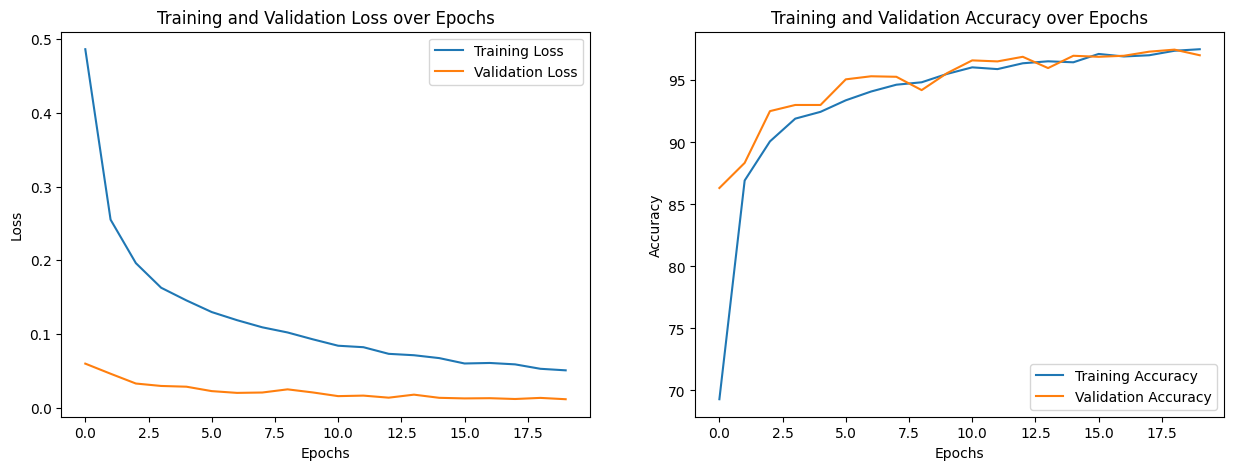

In [54]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 5))

axs[0].plot(total_loss_train_plot, label = 'Training Loss')
axs[0].plot(total_loss_validation_plot, label = 'Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot, label = 'Training Accuracy')
axs[1].plot(total_acc_validation_plot, label = 'Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.show()
     

In [ ]:
def predict_image(image_path):
  image = Image.open(image_path).convert('RGB')
  image = val_transform(image).to(device)
  output = model(image.unsqueeze(0))

  output = torch.argmax(output, axis= 1).item()
  return label_encoder.inverse_transform([output])

In [51]:
predict_image("./afhq/train/cat/flickr_cat_000002.jpg")

array(['cat'], dtype=object)

In [52]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.
